# Computing Full Stokes Beams with TIBEC

This notebook demonstrates how to compute Full Stokes (I, Q, U, V) beam
patterns from an antenna E-field data file using TIBEC.

Two approaches are shown:
1. **Quick path**: `compute_stokes_beams()` — one function call, no class needed
2. **Class-based path**: `E_field` — for LST-dependent beam computation

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from tibec import compute_stokes_beams, load_efield_txt, E_field

## 1. Quick Path: `compute_stokes_beams`

The simplest way to get Full Stokes beams. This assumes the antenna is at
the north pole with standard alignment (x = South, z = Zenith), so the
antenna and equatorial frames coincide — no rotation is needed.

Just provide the E-field file path and the grid dimensions.

In [2]:
stokes, sky_coords = compute_stokes_beams(
    "../data/HIRAX_201-Copy1.txt",
    n_phi=361,
    n_theta=181,
    nside=64
)
print(f"Stokes beams shape: {stokes.shape}")  # (49152, 4)

Stokes beams shape: (49152, 4)


/Users/zzhang/Workspace/TIBEC/tibec/io.py:74: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=65341`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  coords = np.loadtxt(path, comments=comments, usecols=(0, 1),


/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_37131/2355025721.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


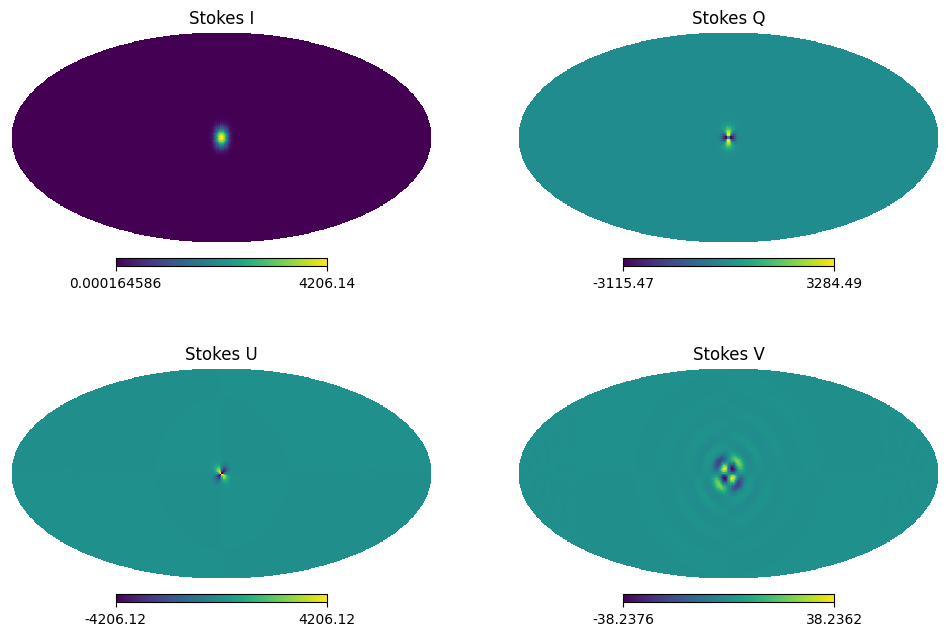

In [3]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
labels = ["Stokes I", "Stokes Q", "Stokes U", "Stokes V"]

for p in range(4):
    plt.axes(axs.flat[p])
    hp.mollview(stokes[:, p], title=labels[p], rot=(0, 90, 0), hold=True)

plt.tight_layout()
plt.show()

## 2. Class-Based Path: LST-Dependent Beams

For instruments not at the pole, or when you need time-dependent beam
patterns, use the `E_field` class. This handles the full coordinate
transformation chain at each Local Sidereal Time (LST).

### Load the E-field data

In [4]:
coords, efield = load_efield_txt(
    "../data/REACH_Efield.txt",
    n_phi=73,
    n_theta=37,
    n_freq=26
)
print(f"Coordinates shape: {coords.shape}")  # (2701, 2)
print(f"E-field shape: {efield.shape}")       # (26, 73, 37, 2)

Coordinates shape: (2701, 2)
E-field shape: (26, 73, 37, 2)


### Create the beam object

Specify the antenna alignment in horizontal (South, East, Zenith) coordinates
and the antenna latitude.

In [5]:
beam = E_field(
    coords, efield,
    alignment_x=[1, 0, 0],   # x-axis points South
    alignment_z=[0, 0, 1],   # z-axis points to Zenith
    ant_lat=np.pi / 2        # north pole
)

The far-field object has been initialized!


### Define sky coordinates and LSTs

In [6]:
# HEALPix sky grid
nside = 32
npix = hp.nside2npix(nside)
sky_coords = np.zeros((npix, 2))
sky_coords[:, 1], sky_coords[:, 0] = hp.pix2ang(nside, np.arange(npix))

# LST range: 0 to 24 hours (in seconds)
LSTs = np.linspace(0, 86400, 10)

### Compute Stokes beams at each LST

In [7]:
stokes_lst = beam.generate_auto_beam_at_LSTs(
    LSTs, sky_coords, freq_ind=0
)
print(f"Shape: {stokes_lst.shape}")  # (10, N_pix, 4)

Shape: (10, 12288, 4)


/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_37131/3314578192.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


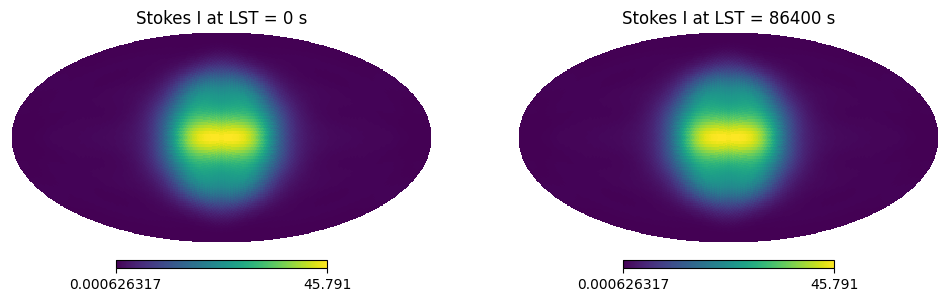

In [8]:
# Plot Stokes I at the first and last LST
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plt.axes(axs[0])
hp.mollview(stokes_lst[0, :, 0],
            title=f"Stokes I at LST = {LSTs[0]:.0f} s",
            rot=(0, 90, 0),
            hold=True)

plt.axes(axs[1])
hp.mollview(stokes_lst[-1, :, 0],
            title=f"Stokes I at LST = {LSTs[-1]:.0f} s",
            rot=(0, 90, 0),
            hold=True)

plt.tight_layout()
plt.show()

### Time-averaged beam

Set `time_averaged=True` to average the E-field over all LSTs before
computing Stokes parameters.

Shape: (12288, 4)


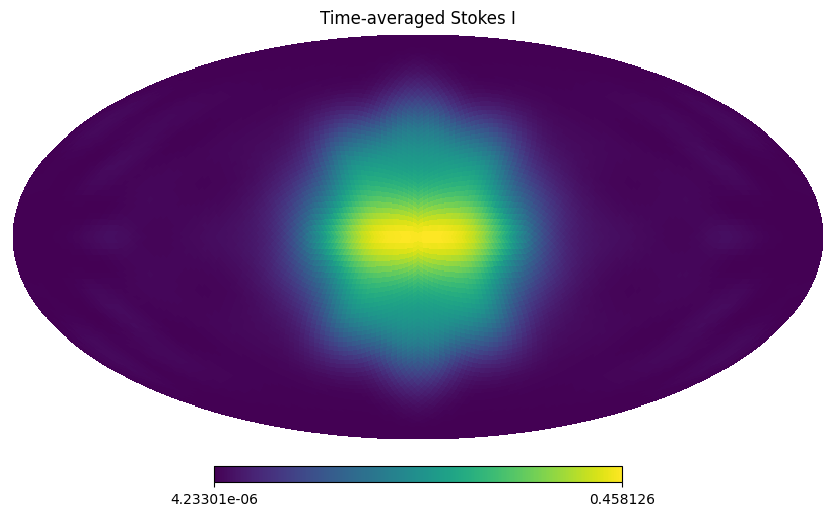

In [9]:
stokes_avg = beam.generate_auto_beam_at_LSTs(
    LSTs, sky_coords, freq_ind=0, time_averaged=True
)
print(f"Shape: {stokes_avg.shape}")  # (N_pix, 4)

hp.mollview(stokes_avg[:, 0], title="Time-averaged Stokes I", rot=(0, 90, 0))
plt.show()